In [24]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [25]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [26]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     367   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        66   (2094, 964)   float32   


In [27]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Text(0.5, 0, 'wavelength')

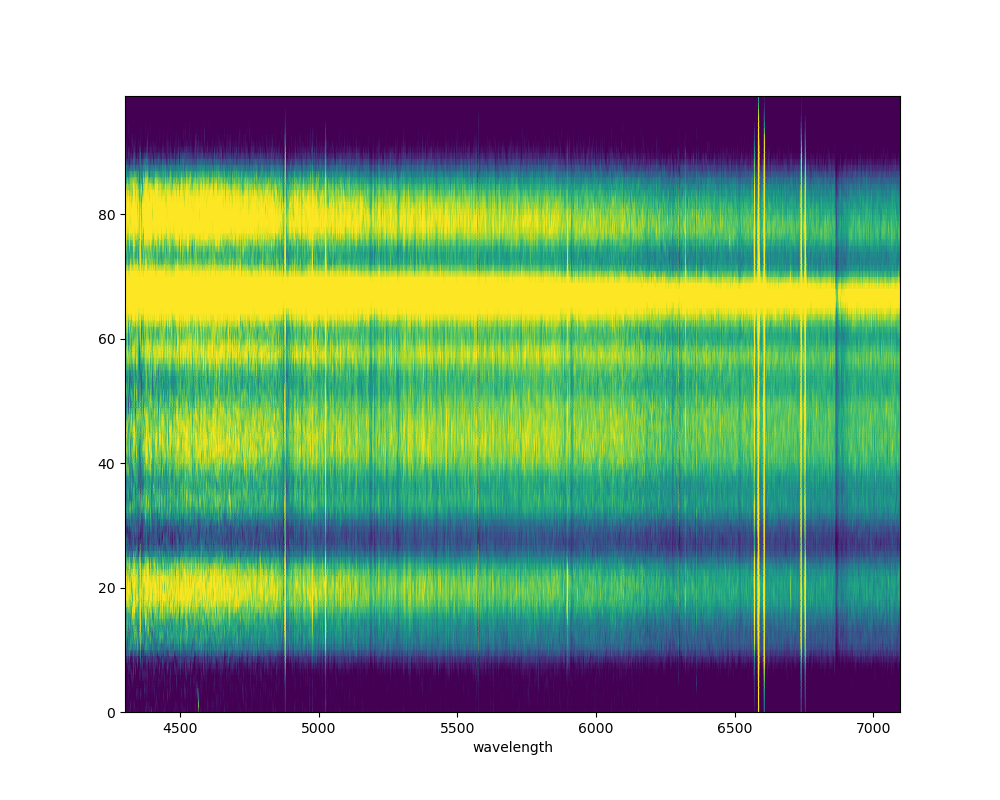

In [28]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [29]:
z = 0.00394
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/PSF/Real_seeing_NGC4904.txt")
sigmas = seeing / 2.35
n_component = 5
print(sigmas)

[1.51856596 1.65489801 1.51814012 1.51674365 1.63857526 1.51957447]


In [30]:
l_HA

6588.85822

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     367   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        66   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

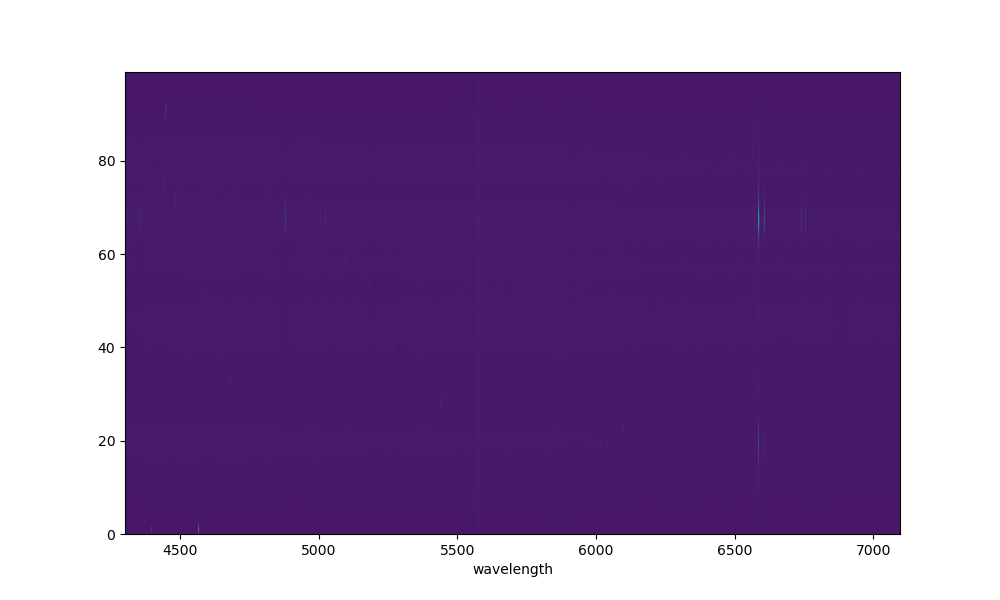

In [31]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[49:149, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

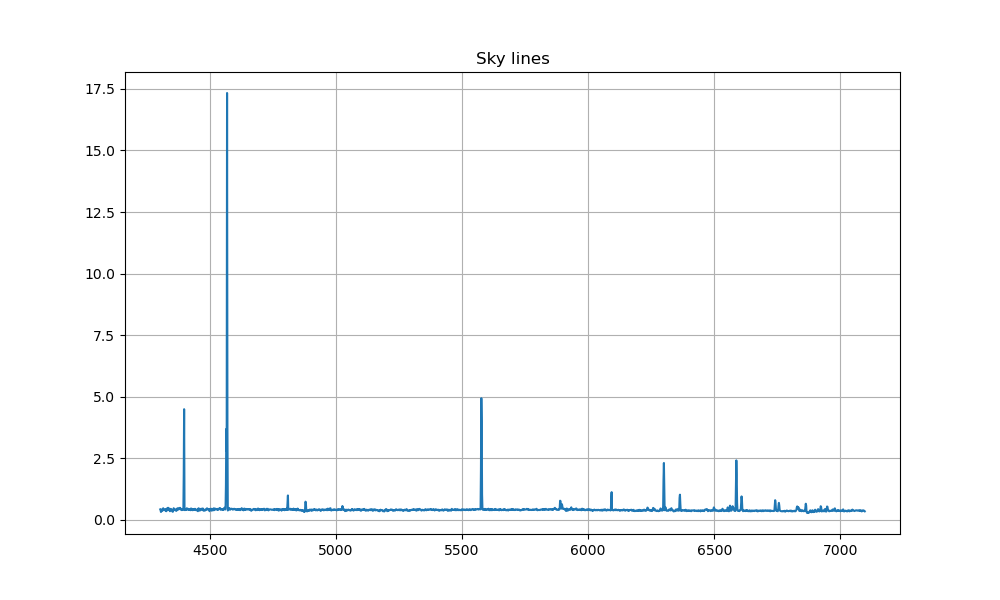

In [32]:
mask_sky = (y > 0)*(y < 8)
mask_wv = wv > 4303
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

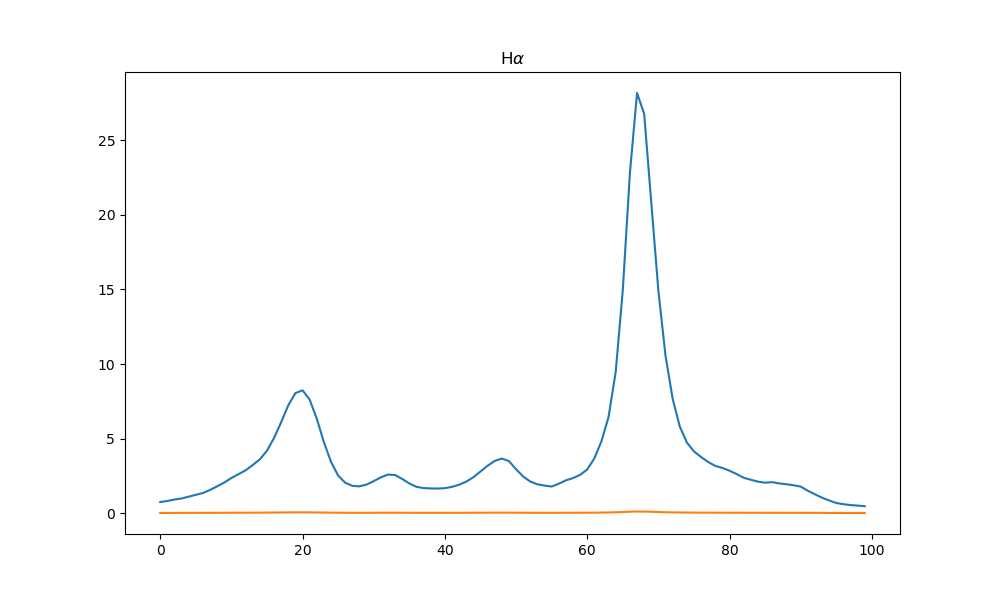

In [33]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [34]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [

    (0, 20),
    (0, 50),
    (0.1, 10),
    (15, 25),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (29, 33),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (78, 82)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

In [35]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 260765.02145761778
differential_evolution step 2: f(x)= 49610.68033117854
differential_evolution step 3: f(x)= 49610.68033117854
differential_evolution step 4: f(x)= 49610.68033117854
differential_evolution step 5: f(x)= 23170.499680639303
differential_evolution step 6: f(x)= 23170.499680639303
differential_evolution step 7: f(x)= 20681.901062681627
differential_evolution step 8: f(x)= 16194.179595114303
differential_evolution step 9: f(x)= 16194.179595114303
differential_evolution step 10: f(x)= 7482.6419781760305
differential_evolution step 11: f(x)= 6139.040638879374
differential_evolution step 12: f(x)= 3016.524624213475
differential_evolution step 13: f(x)= 3016.524624213475
differential_evolution step 14: f(x)= 3016.524624213475
differential_evolution step 15: f(x)= 3016.524624213475
differential_evolution step 16: f(x)= 3002.3481897007136
differential_evolution step 17: f(x)= 3002.3481897007136
differential_evolution step 18: f(x)= 3002.34818

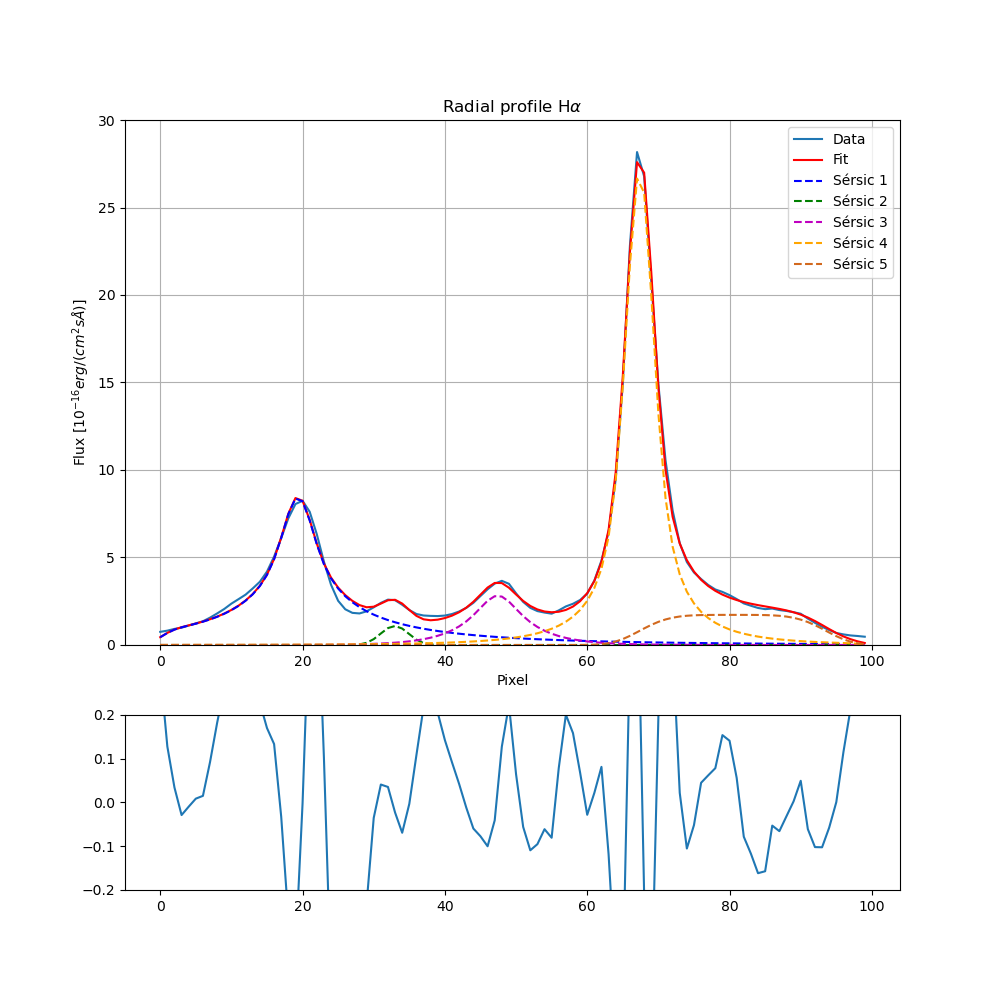

In [36]:
plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [38]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, 
                                           p0=result.x, sigma = radial_profile_error_HA, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, radial_profile_error_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1977, r_e=49.9772, n=2.4998, x_0=19.1453
Sérsic 2: I_e=1.1195, r_e=1.7612, n=0.1000, x_0=33.0000
Sérsic 3: I_e=0.6469, r_e=7.3832, n=1.0247, x_0=47.4310
Sérsic 4: I_e=1.5333, r_e=9.0926, n=2.3454, x_0=67.4252
Sérsic 5: I_e=1.2245, r_e=10.5127, n=0.3281, x_0=80.1128
[ 0.09643219 19.71960906  0.34177653  0.1009709  17.89080777 34.58662561
  5.5238662   0.33033025  0.33889964  3.24600282  0.36472141  0.28644288
  0.76957554  2.90379223  0.42795542  0.04016332  0.42537665  3.64882897
  0.13931275  6.34279282]
50.7630327889139


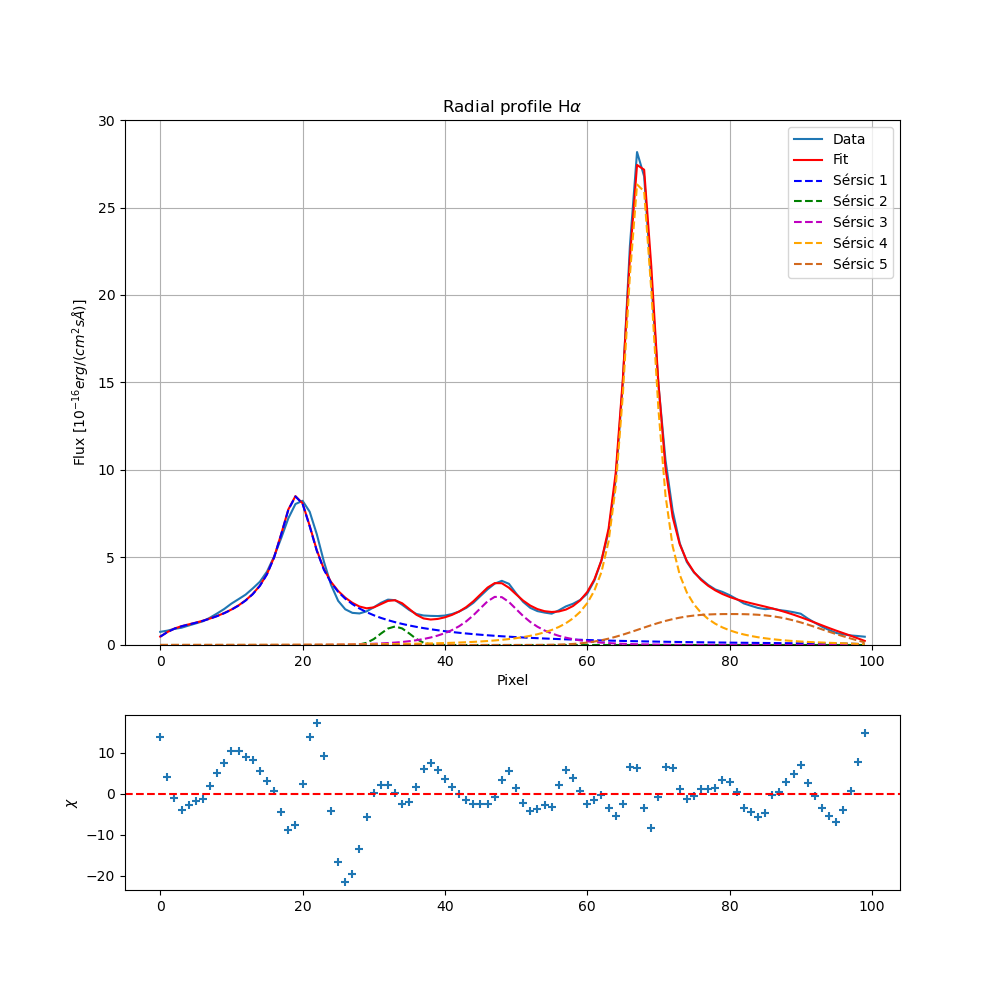

In [39]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [43]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.8, x_0_HA[0]+1.8),   # x_0: circa la posizione di Halpha

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.8, x_0_HA[1]+1.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.8, x_0_HA[2]+1.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.8, x_0_HA[3]+1.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.8, x_0_HA[4]+1.8)
]

In [44]:
bounds

[(0, 20),
 (0, 50),
 (0.1, 10),
 (17.345299999999998, 20.9453),
 (0, 20),
 (0, 50),
 (0.1, 10),
 (31.2, 34.8),
 (0, 20),
 (0, 50),
 (0.1, 10),
 (45.631, 49.230999999999995),
 (0, 20),
 (0, 50),
 (0.1, 10),
 (65.6252, 69.2252),
 (0, 20),
 (0, 50),
 (0.1, 10),
 (78.3128, 81.91279999999999)]

## H$\beta$

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16052\1466757207.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


Text(0.5, 1.0, 'H$\\beta$')

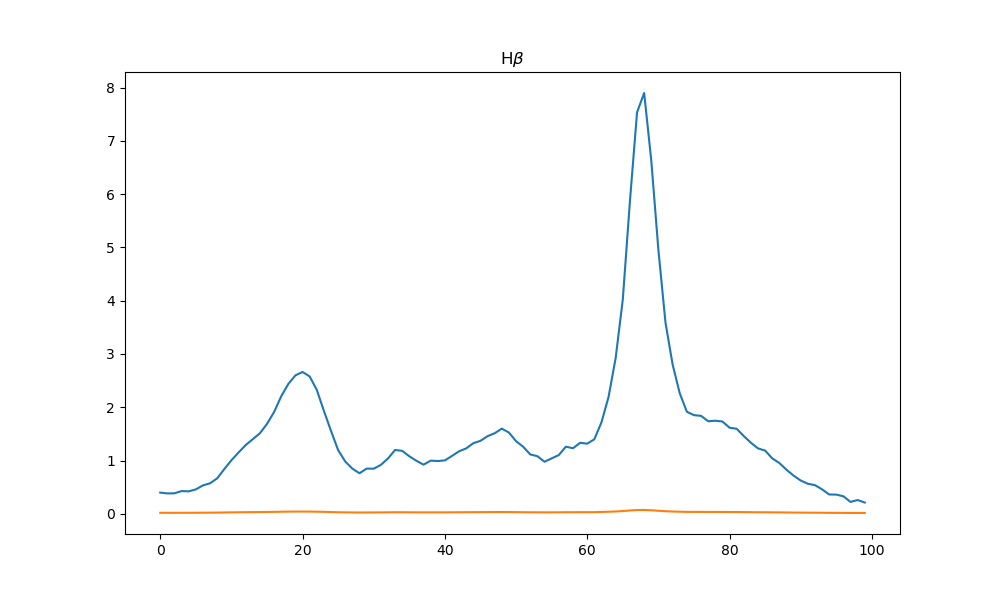

In [45]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [46]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 108295.71048558112
differential_evolution step 2: f(x)= 108295.71048558112
differential_evolution step 3: f(x)= 108295.71048558112
differential_evolution step 4: f(x)= 21905.131222024105
differential_evolution step 5: f(x)= 13227.955720531625
differential_evolution step 6: f(x)= 13227.955720531625
differential_evolution step 7: f(x)= 793.281609121069
differential_evolution step 8: f(x)= 793.281609121069
differential_evolution step 9: f(x)= 793.281609121069
differential_evolution step 10: f(x)= 793.281609121069
differential_evolution step 11: f(x)= 793.281609121069
differential_evolution step 12: f(x)= 793.281609121069
differential_evolution step 13: f(x)= 793.281609121069
differential_evolution step 14: f(x)= 654.6878267731983
differential_evolution step 15: f(x)= 595.4244623981712
differential_evolution step 16: f(x)= 595.4244623981712
differential_evolution step 17: f(x)= 595.4244623981712
differential_evolution step 18: f(x)= 595.4244623981712
di

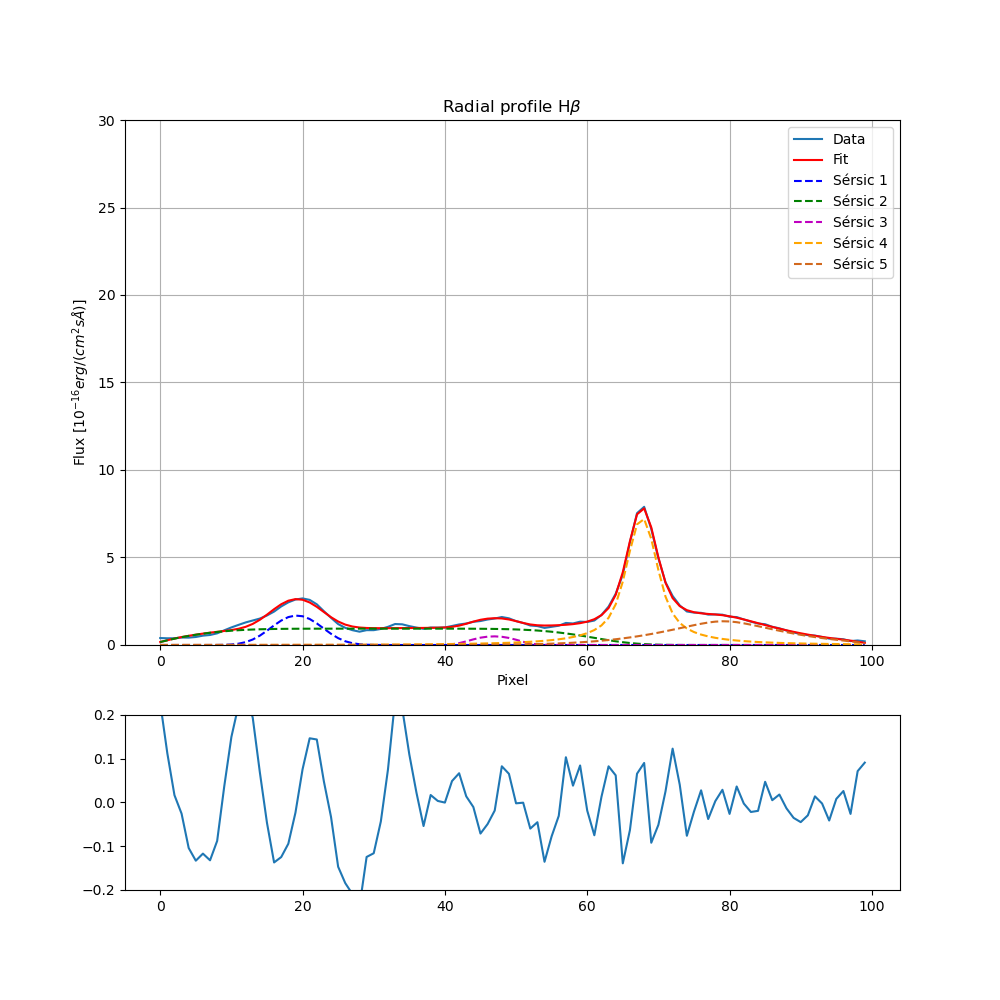

In [47]:
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [48]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, radial_profile_error_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.1137, r_e=3.5082, n=0.3862, x_0=18.9120
Sérsic 2: I_e=0.7734, r_e=21.3976, n=0.2052, x_0=31.5510
Sérsic 3: I_e=0.4694, r_e=2.8485, n=0.1459, x_0=46.9001
Sérsic 4: I_e=0.2114, r_e=14.8514, n=2.8931, x_0=67.7082
Sérsic 5: I_e=0.4334, r_e=12.8238, n=0.7631, x_0=79.2817
[2.03449278e-01 3.27728537e-01 1.46967802e-01 1.71380540e-01
 1.28610870e-01 2.22140175e+00 5.01116261e-02 3.41317167e+00
 7.88526278e-02 3.72542810e+00 8.22171175e-01 4.31060142e-01
 8.92360224e-01 4.70466888e+01 4.10374507e+00 2.41636304e-03
 1.70852032e-01 3.40724252e+00 1.43015743e-01 1.31790121e+00]
14.56291951841072


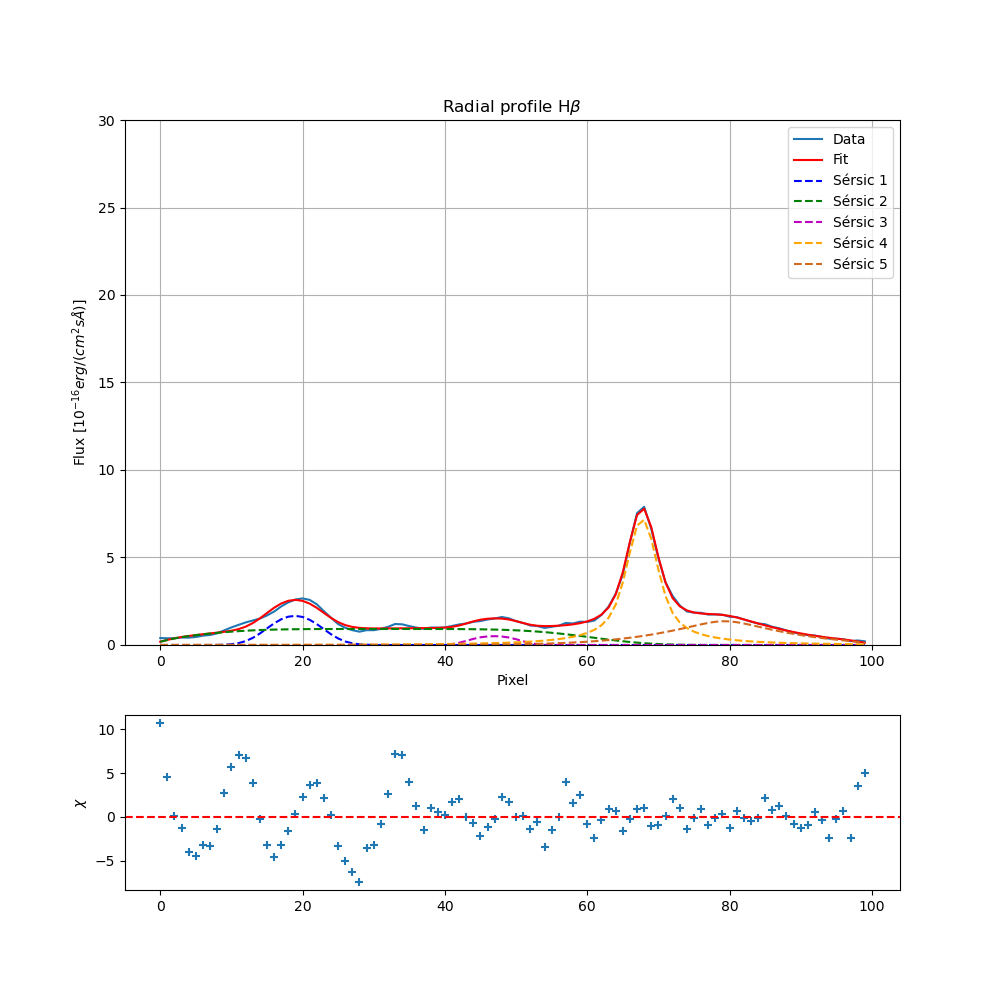

In [49]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

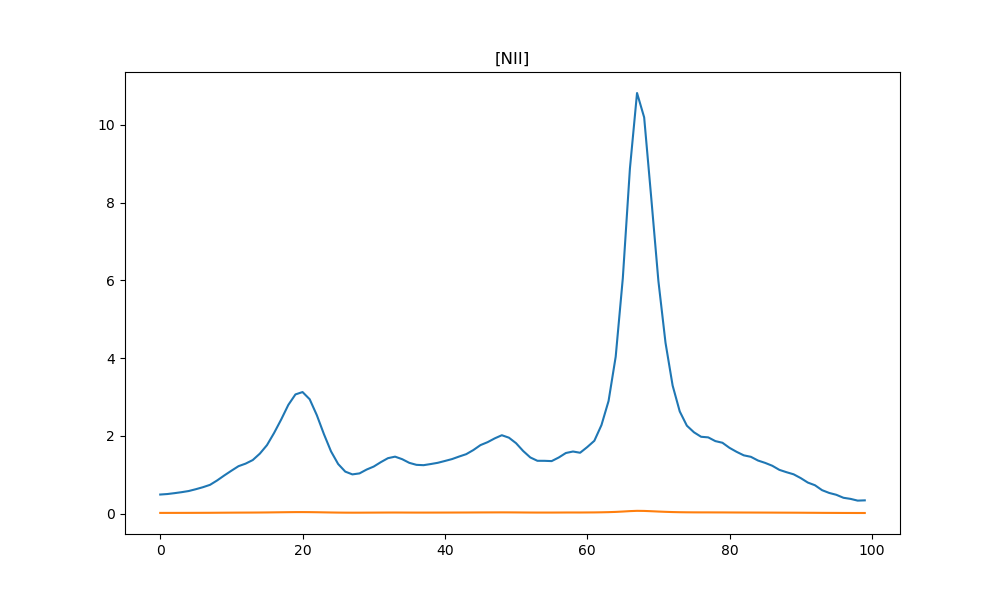

In [50]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [51]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 357292.7085471815
differential_evolution step 2: f(x)= 89367.49216347253
differential_evolution step 3: f(x)= 89367.49216347253
differential_evolution step 4: f(x)= 44726.37989063312
differential_evolution step 5: f(x)= 44726.37989063312
differential_evolution step 6: f(x)= 39263.79519652202
differential_evolution step 7: f(x)= 14204.352207427777
differential_evolution step 8: f(x)= 8217.225986627065
differential_evolution step 9: f(x)= 8217.225986627065
differential_evolution step 10: f(x)= 1895.492730035003
differential_evolution step 11: f(x)= 1895.492730035003
differential_evolution step 12: f(x)= 1895.492730035003
differential_evolution step 13: f(x)= 1895.492730035003
differential_evolution step 14: f(x)= 1895.492730035003
differential_evolution step 15: f(x)= 218.019480526514
differential_evolution step 16: f(x)= 218.019480526514
differential_evolution step 17: f(x)= 218.019480526514
differential_evolution step 18: f(x)= 218.019480526514
diff

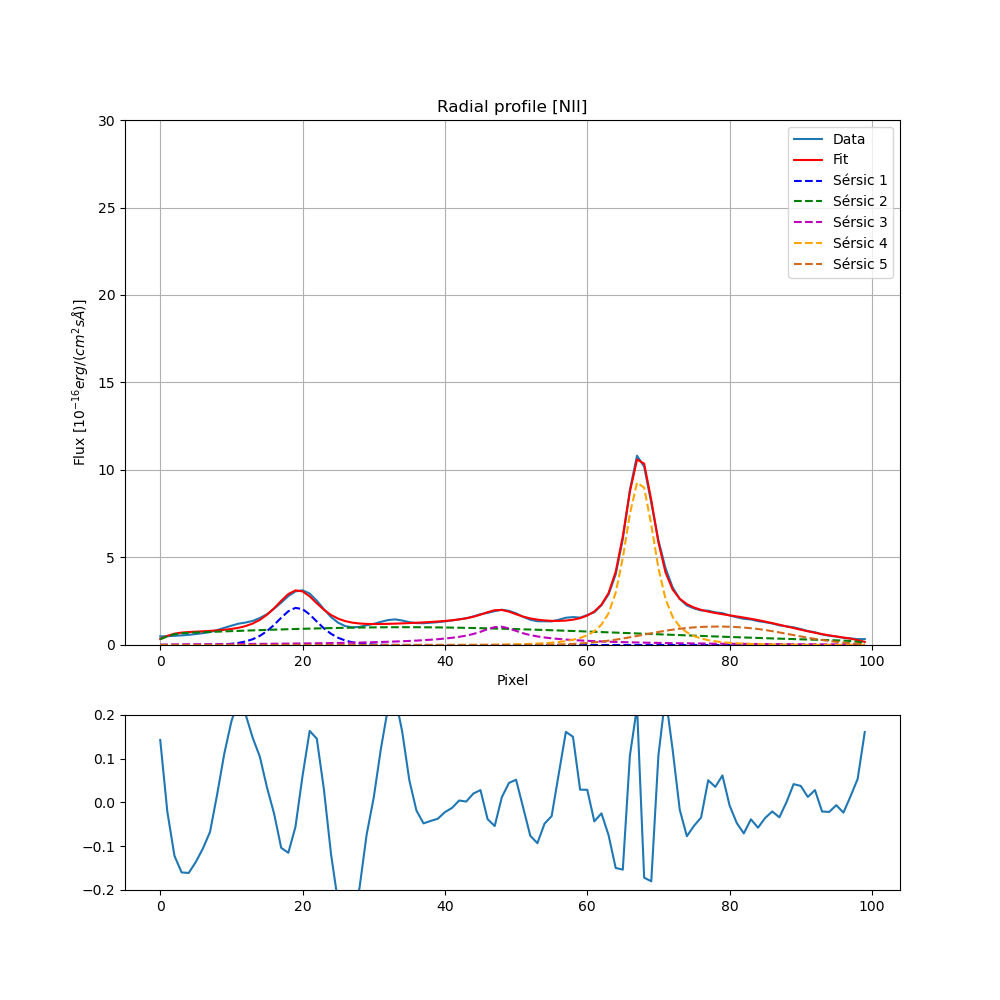

In [52]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [53]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = radial_profile_error_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, radial_profile_error_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.9114, r_e=3.7017, n=0.6936, x_0=19.0117
Sérsic 2: I_e=0.3927, r_e=50.0000, n=0.6381, x_0=34.8000
Sérsic 3: I_e=0.0336, r_e=50.0000, n=2.2189, x_0=47.6655
Sérsic 4: I_e=0.8654, r_e=5.8806, n=2.0644, x_0=67.3967
Sérsic 5: I_e=0.5674, r_e=10.1787, n=0.4387, x_0=78.3128
[2.18934643e-01 5.83160621e-01 1.89472447e-01 1.39464425e-01
 6.69709991e-01 3.57633564e+01 4.18412764e-01 2.32645724e+01
 3.88126761e-01 8.21458911e+02 7.18700523e+00 4.09698608e-01
 1.48140086e+00 9.31847848e+00 1.22561540e+00 5.67880325e-02
 4.04634872e-01 5.52242121e+00 2.07110569e-01 8.52781486e+00]
22.276475937634977


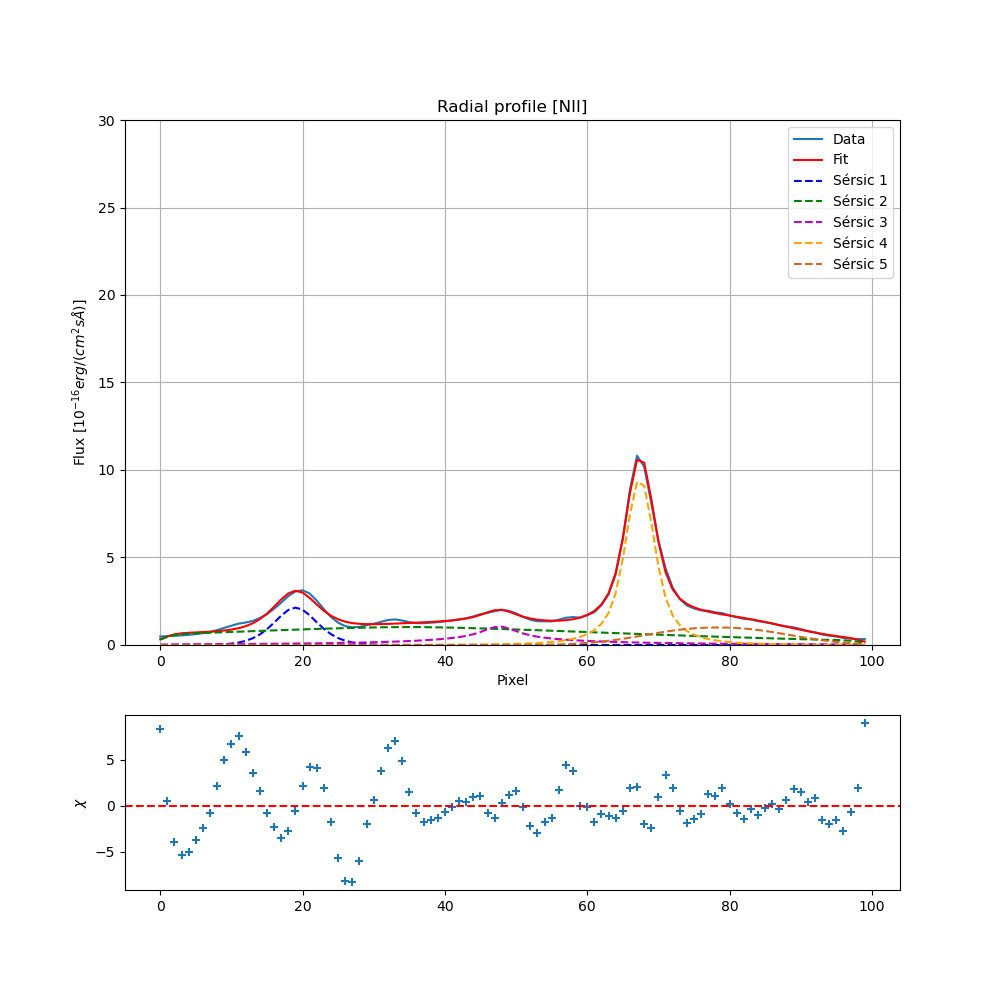

In [54]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

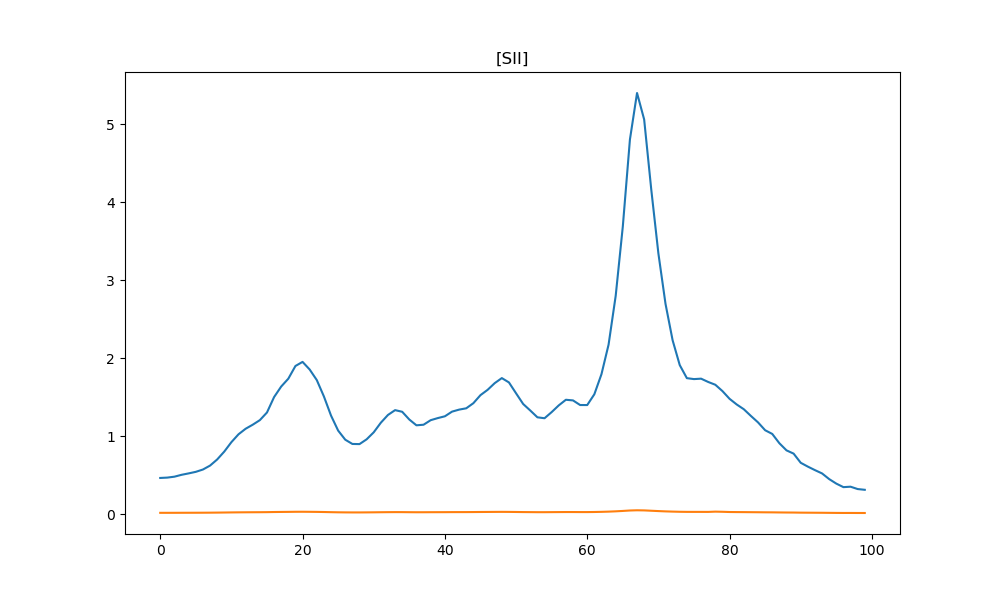

In [55]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [56]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 35485.46390038083
differential_evolution step 2: f(x)= 35485.46390038083
differential_evolution step 3: f(x)= 35485.46390038083
differential_evolution step 4: f(x)= 35485.46390038083
differential_evolution step 5: f(x)= 33591.07934622287
differential_evolution step 6: f(x)= 33591.07934622287
differential_evolution step 7: f(x)= 17380.09019223365
differential_evolution step 8: f(x)= 14910.172585741288
differential_evolution step 9: f(x)= 14910.172585741288
differential_evolution step 10: f(x)= 1127.5240362673237
differential_evolution step 11: f(x)= 1127.5240362673237
differential_evolution step 12: f(x)= 1127.5240362673237
differential_evolution step 13: f(x)= 1127.5240362673237
differential_evolution step 14: f(x)= 1127.5240362673237
differential_evolution step 15: f(x)= 1110.2300393039848
differential_evolution step 16: f(x)= 1110.2300393039848
differential_evolution step 17: f(x)= 1110.2300393039848
differential_evolution step 18: f(x)= 1110.2300

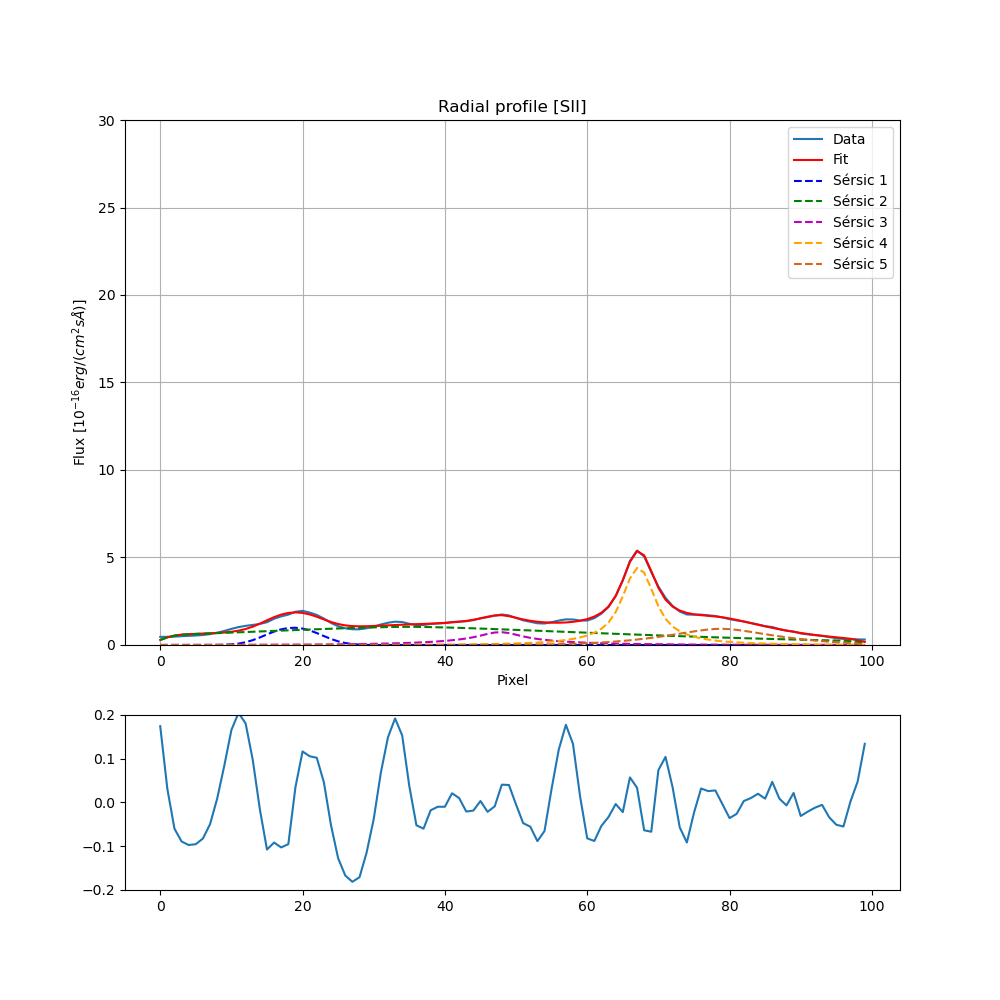

In [57]:
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [58]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, radial_profile_error_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.6267, r_e=3.8970, n=0.3949, x_0=18.4427
Sérsic 2: I_e=0.3219, r_e=50.0000, n=0.6895, x_0=34.8000
Sérsic 3: I_e=0.0346, r_e=49.9994, n=1.9986, x_0=47.6309
Sérsic 4: I_e=0.2551, r_e=11.1176, n=2.2130, x_0=67.2179
Sérsic 5: I_e=0.3406, r_e=10.2417, n=0.6551, x_0=78.9667
[1.21194825e-01 5.52808273e-01 1.63769074e-01 2.29223415e-01
 3.55043281e-01 4.87700438e+01 4.93849245e-01 1.21564287e+01
 4.35429824e-01 7.46705677e+02 8.26329029e+00 2.67861006e-01
 4.90041274e-01 1.91183086e+01 1.35091364e+00 7.96479494e-02
 1.09810653e-01 5.08219722e+00 2.51227656e-01 1.07756989e+00]
16.85438230182576


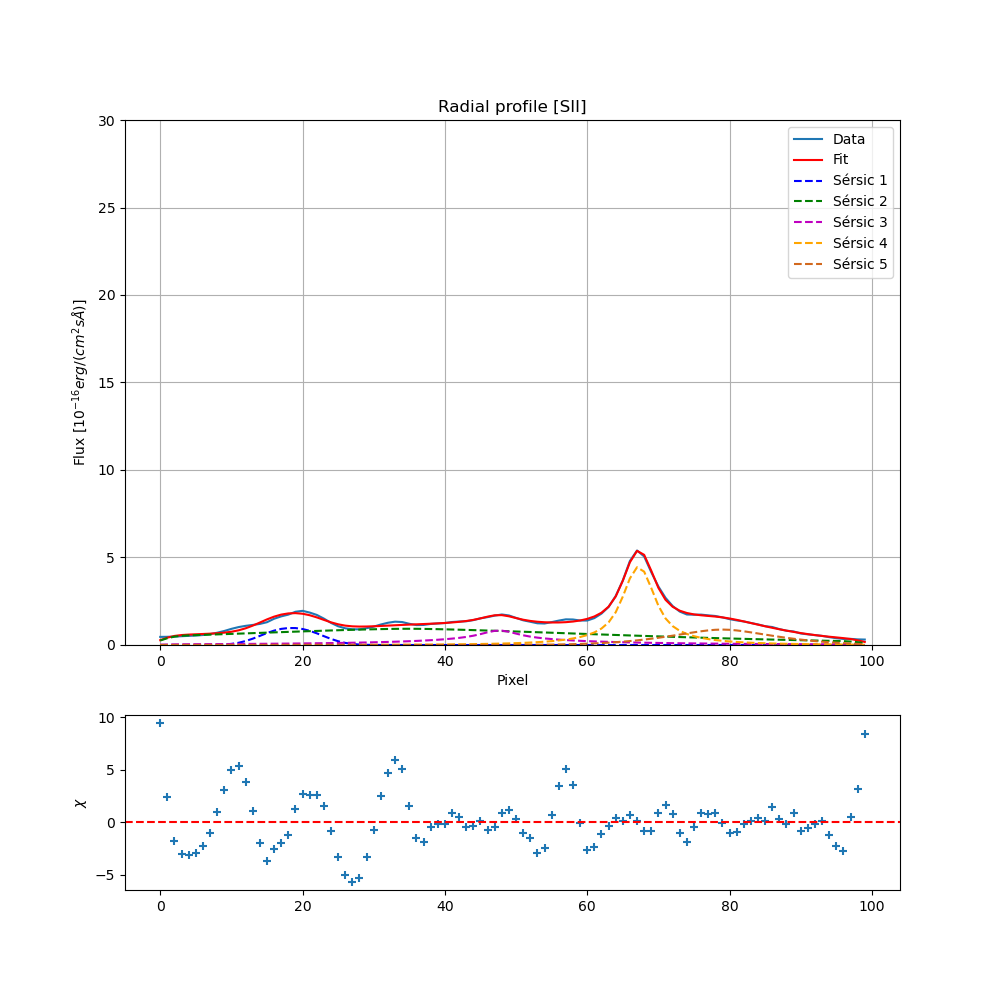

In [59]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

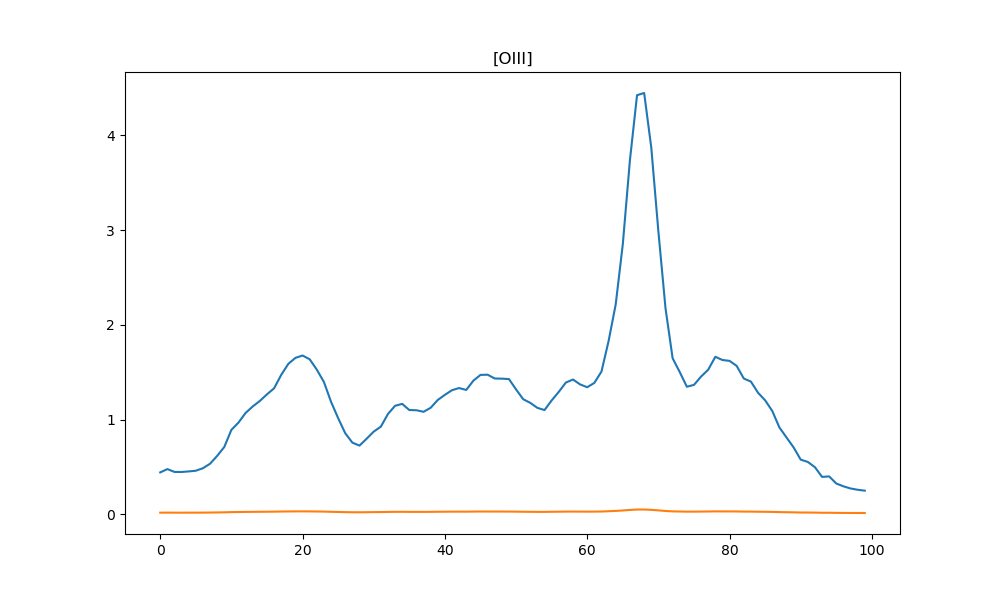

In [60]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [61]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 311098.89394261135
differential_evolution step 2: f(x)= 190026.8298312184
differential_evolution step 3: f(x)= 102328.01102863983
differential_evolution step 4: f(x)= 79613.82648032051
differential_evolution step 5: f(x)= 79613.82648032051
differential_evolution step 6: f(x)= 79613.82648032051
differential_evolution step 7: f(x)= 79613.82648032051
differential_evolution step 8: f(x)= 48788.53757097677
differential_evolution step 9: f(x)= 19130.49577888199
differential_evolution step 10: f(x)= 19130.49577888199
differential_evolution step 11: f(x)= 7835.531181786836
differential_evolution step 12: f(x)= 7835.531181786836
differential_evolution step 13: f(x)= 7835.531181786836
differential_evolution step 14: f(x)= 7835.531181786836
differential_evolution step 15: f(x)= 615.5096190913139
differential_evolution step 16: f(x)= 615.5096190913139
differential_evolution step 17: f(x)= 615.5096190913139
differential_evolution step 18: f(x)= 615.5096190913139

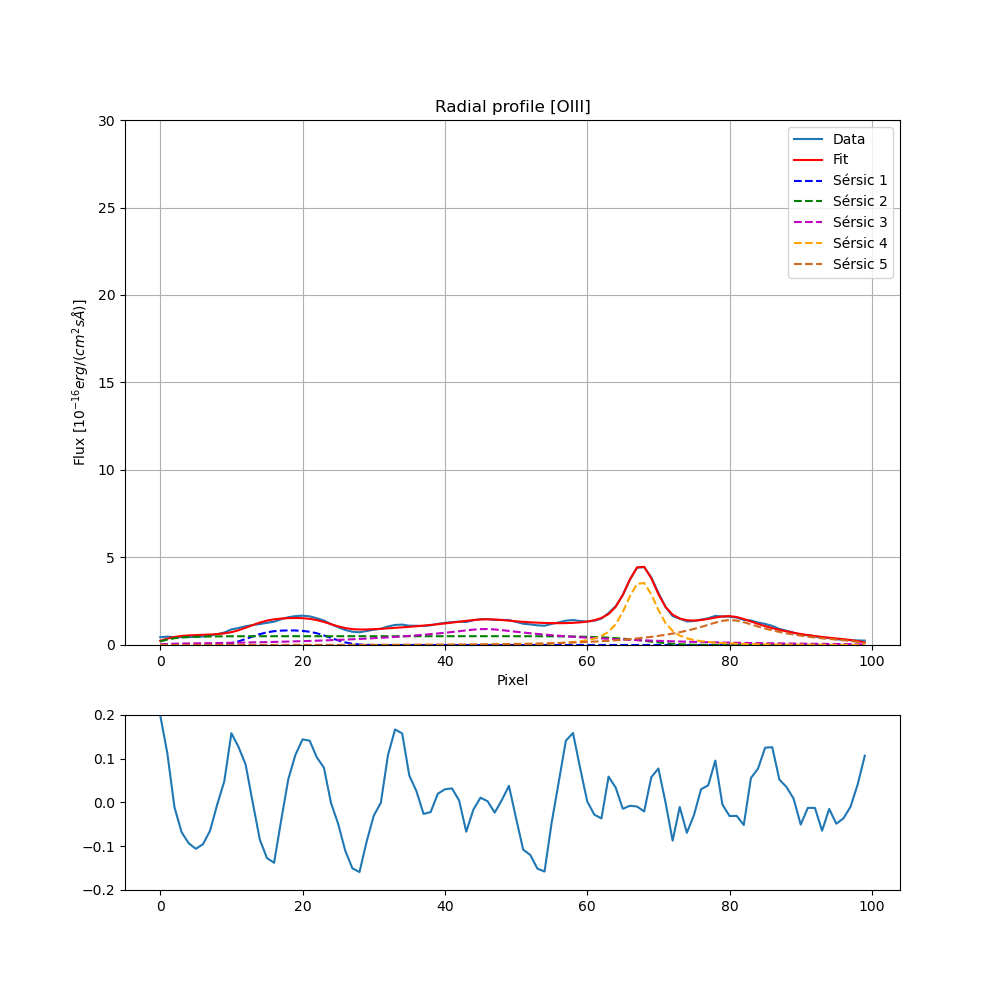

In [62]:
# Plots:
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [63]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = radial_profile_error_OIII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, radial_profile_error_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.7671, r_e=4.7462, n=0.2008, x_0=17.7653
Sérsic 2: I_e=0.2554, r_e=39.5230, n=0.0506, x_0=28.2995
Sérsic 3: I_e=0.2971, r_e=16.8352, n=0.7025, x_0=44.5487
Sérsic 4: I_e=0.2019, r_e=9.5811, n=2.4128, x_0=67.6092
Sérsic 5: I_e=0.3335, r_e=14.6898, n=0.9752, x_0=80.3020
[6.46429084e-02 2.25923521e-01 9.44305743e-02 2.52406923e-01
 3.24223563e+00 3.52008128e+02 4.23196496e-01 3.12207921e+02
 1.15761331e-01 7.43941761e+00 2.42930733e-01 1.19035583e+00
 8.27908753e-01 2.58205274e+01 4.70164213e+00 9.03526563e-03
 8.41080384e-02 2.86707688e+00 1.53340573e-01 4.40954373e-01]
11.071911876889775


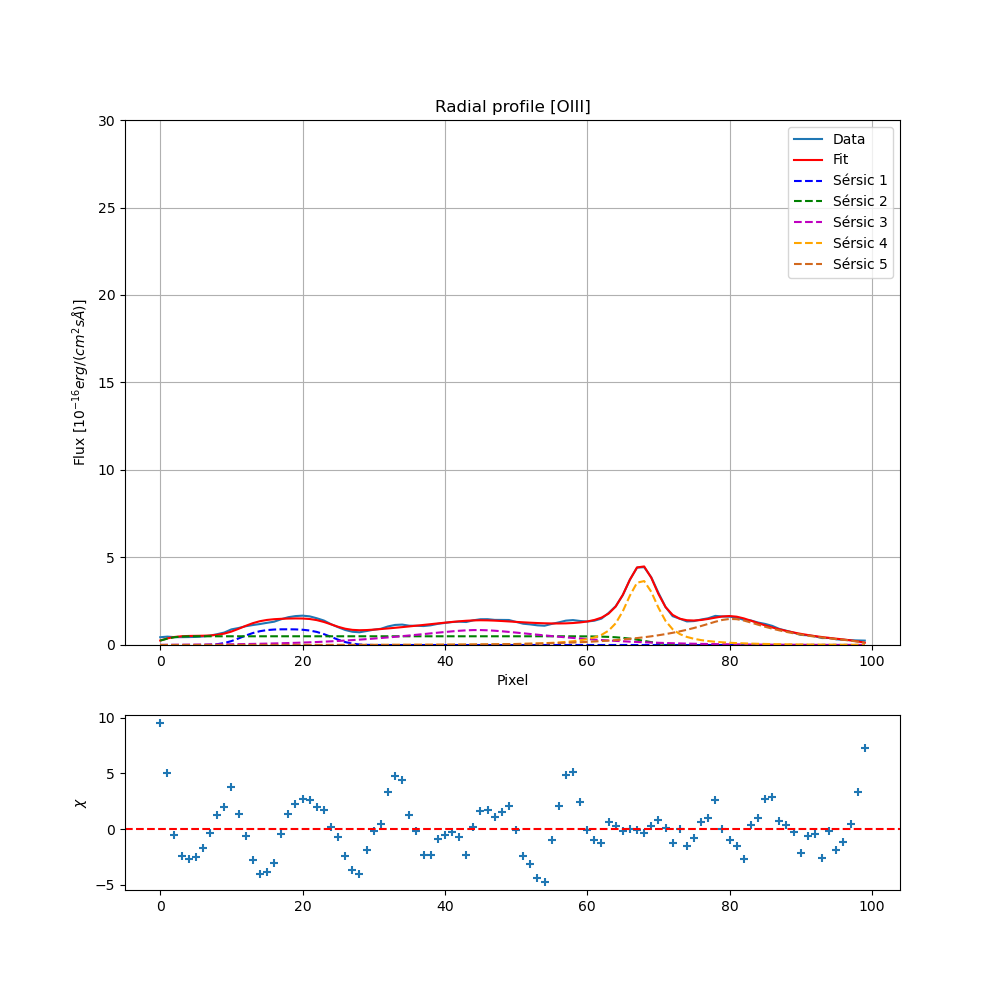

In [64]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [65]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

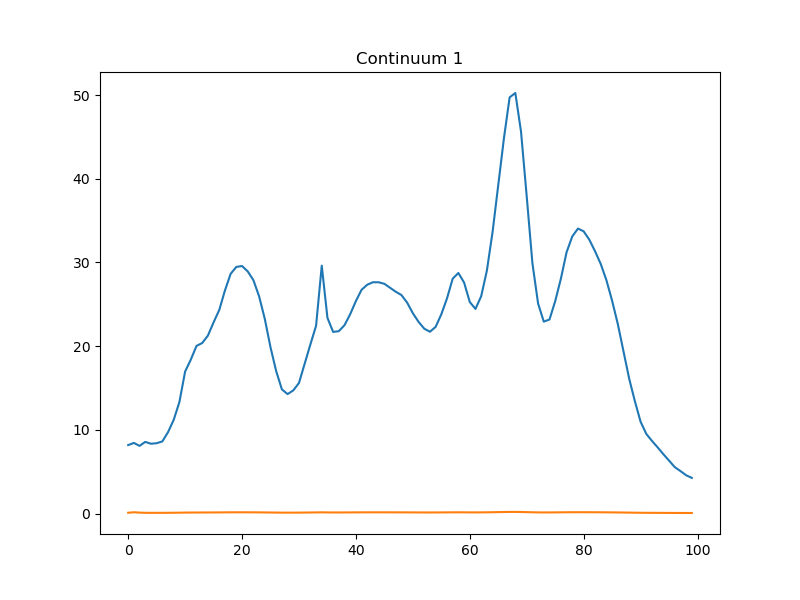

In [66]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [67]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 93965.07488737238
differential_evolution step 2: f(x)= 93965.07488737238
differential_evolution step 3: f(x)= 40586.60765054275
differential_evolution step 4: f(x)= 40586.60765054275
differential_evolution step 5: f(x)= 40586.60765054275
differential_evolution step 6: f(x)= 40586.60765054275
differential_evolution step 7: f(x)= 40586.60765054275
differential_evolution step 8: f(x)= 40586.60765054275
differential_evolution step 9: f(x)= 13297.10472295751
differential_evolution step 10: f(x)= 13297.10472295751
differential_evolution step 11: f(x)= 13297.10472295751
differential_evolution step 12: f(x)= 13297.10472295751
differential_evolution step 13: f(x)= 9839.421600901187
differential_evolution step 14: f(x)= 9839.421600901187
differential_evolution step 15: f(x)= 9839.421600901187
differential_evolution step 16: f(x)= 9839.421600901187
differential_evolution step 17: f(x)= 9839.421600901187
differential_evolution step 18: f(x)= 9839.421600901187
d

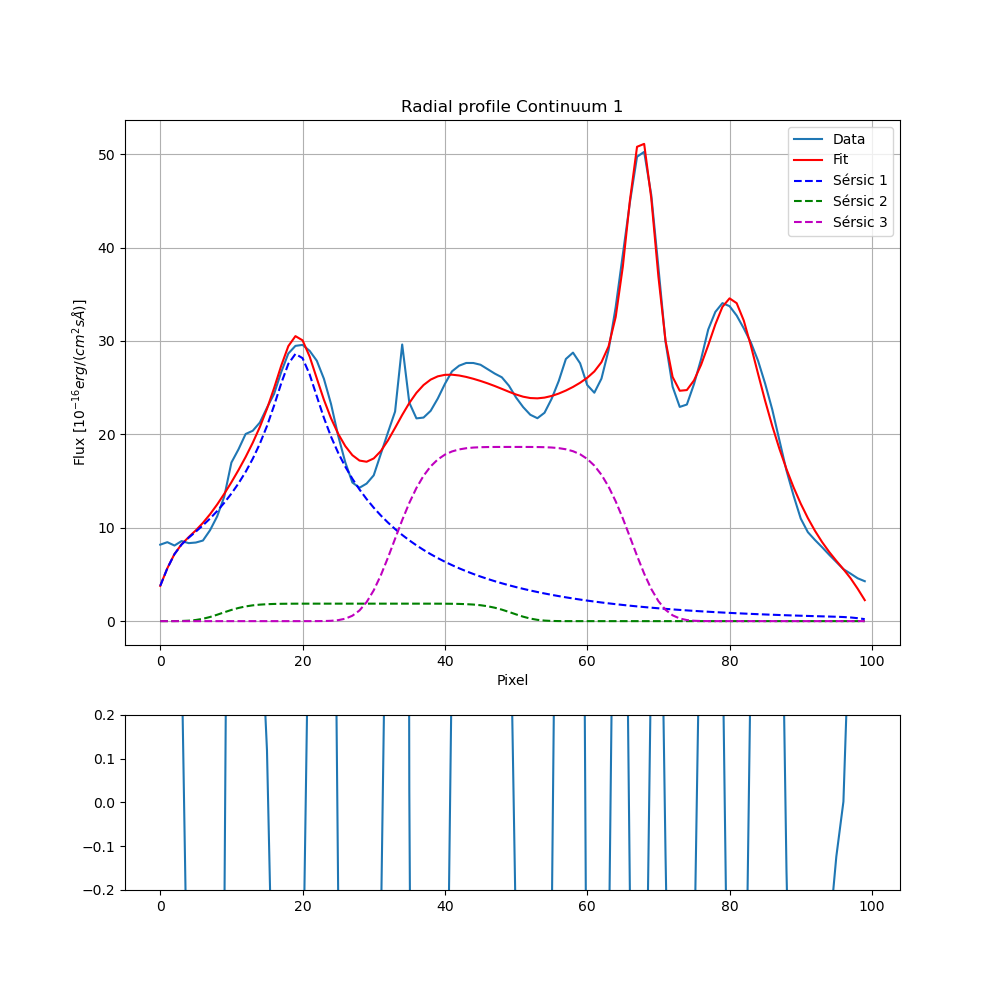

In [68]:
def plot_curve(x_axes, params_curve, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_error_HA, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24]), color = 'purple', linestyle='--', label='Sérsic 6')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 15)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)
    
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [69]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = radial_profile_error_continuum_1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, radial_profile_continuum_1, radial_profile_error_continuum_1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=3.2327, r_e=30.9297, n=1.3600, x_0=19.0494
Sérsic 2: I_e=1.6448, r_e=16.9958, n=0.1000, x_0=29.1180
Sérsic 3: I_e=16.8849, r_e=12.2269, n=0.1715, x_0=49.6255
Sérsic 4: I_e=2.5978, r_e=8.6517, n=2.1684, x_0=67.6756
Sérsic 5: I_e=8.2946, r_e=12.0500, n=0.9179, x_0=80.3141
[ 2.62157322 20.44263174  0.4529938   0.36974786  3.18316235 17.91218754
  0.29357496  3.84828501  2.83055448  1.29383461  0.04325812  1.75685029
  7.76211121 19.95530201  2.23965508  0.23644801  1.96841704  1.67074512
  0.13207487  0.47504399]
194.9372596711566


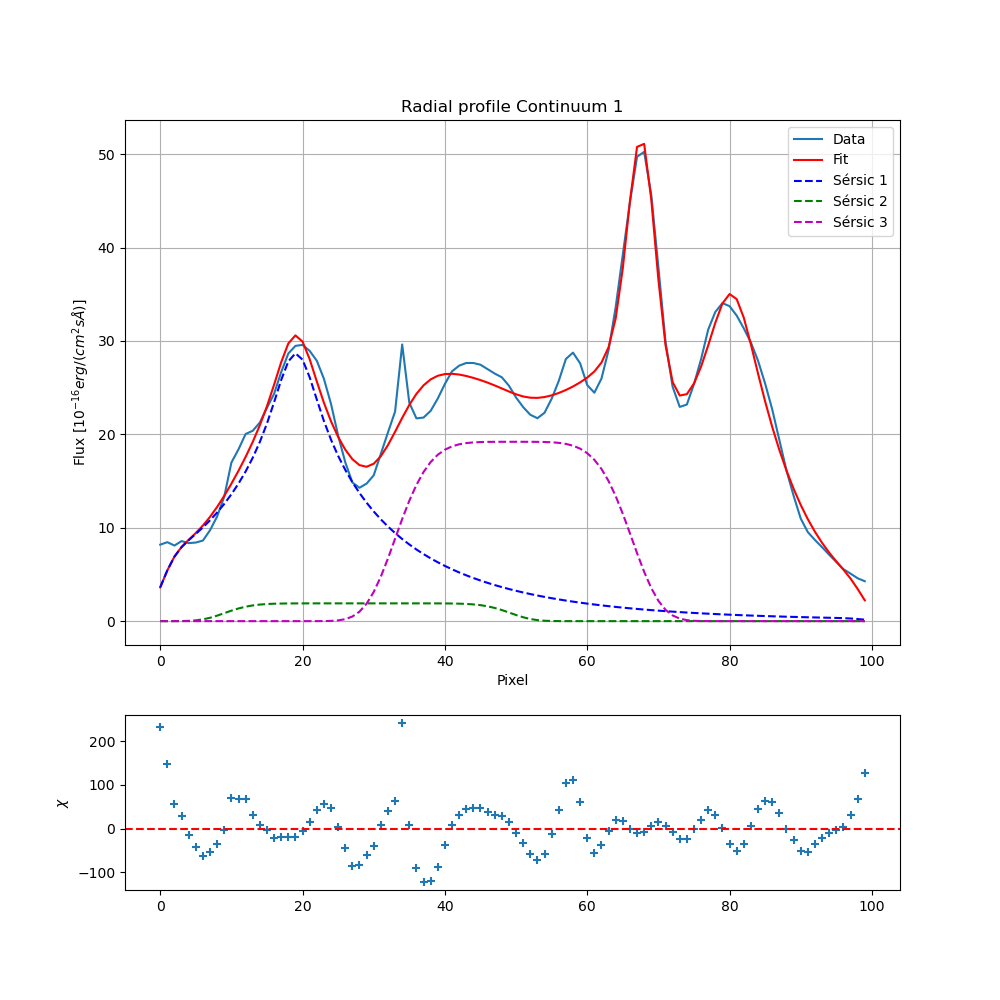

In [70]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

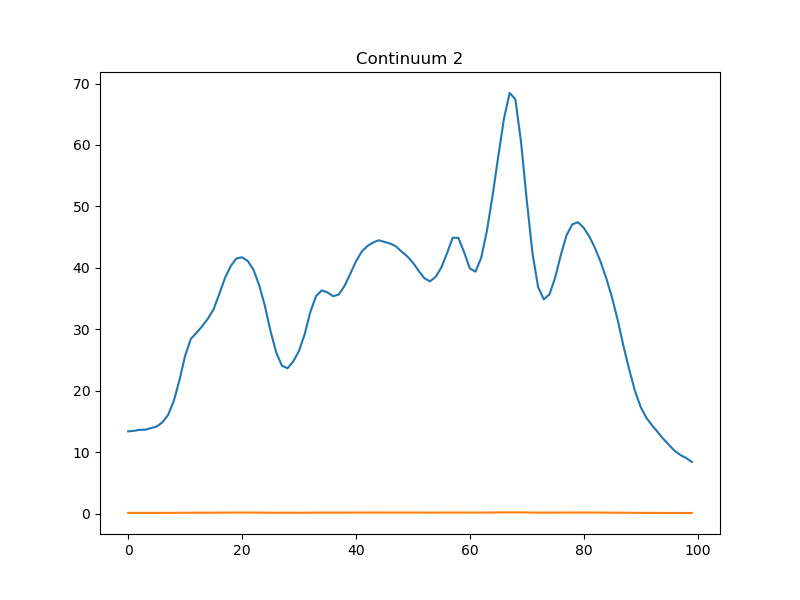

In [71]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [72]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 157566.99813751713
differential_evolution step 2: f(x)= 38340.530037249686
differential_evolution step 3: f(x)= 20346.31135783875
differential_evolution step 4: f(x)= 7077.11114692793
differential_evolution step 5: f(x)= 7077.11114692793
differential_evolution step 6: f(x)= 7077.11114692793
differential_evolution step 7: f(x)= 7077.11114692793
differential_evolution step 8: f(x)= 7077.11114692793
differential_evolution step 9: f(x)= 7077.11114692793
differential_evolution step 10: f(x)= 7077.11114692793
differential_evolution step 11: f(x)= 7077.11114692793
differential_evolution step 12: f(x)= 7077.11114692793
differential_evolution step 13: f(x)= 7077.11114692793
differential_evolution step 14: f(x)= 7077.11114692793
differential_evolution step 15: f(x)= 7053.937085415832
differential_evolution step 16: f(x)= 7053.937085415832
differential_evolution step 17: f(x)= 6850.520099729111
differential_evolution step 18: f(x)= 4514.693769535452
differenti

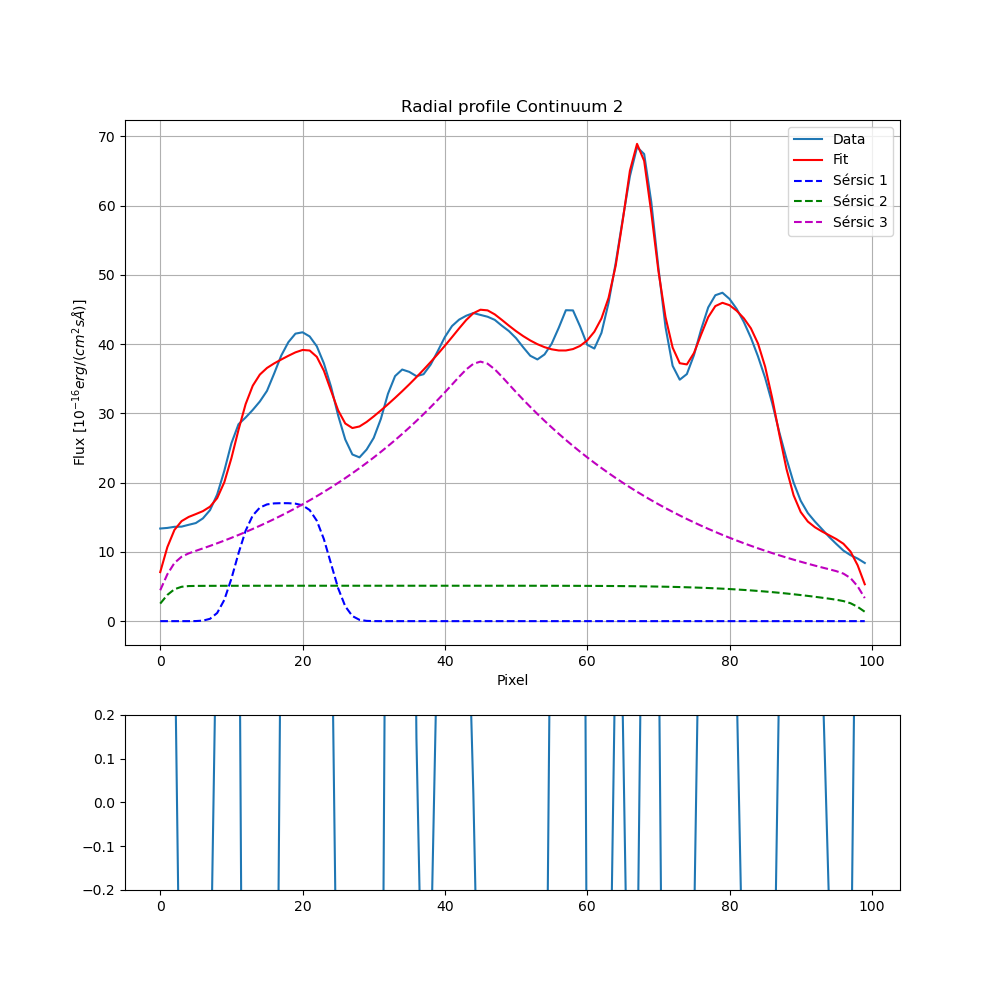

In [73]:
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[5], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [74]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[5], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = radial_profile_error_continuum_2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2, radial_profile_error_continuum_2,
                                                                          sigmas[5], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=14.8456, r_e=5.5771, n=0.1156, x_0=17.2262
Sérsic 2: I_e=5.0070, r_e=49.3771, n=0.1757, x_0=32.8602
Sérsic 3: I_e=6.9345, r_e=49.3938, n=1.0176, x_0=45.0130
Sérsic 4: I_e=2.0018, r_e=25.4679, n=2.1268, x_0=67.1883
Sérsic 5: I_e=18.9268, r_e=4.2206, n=0.2380, x_0=81.2045
[3.35894039e+00 1.93674878e+00 1.19985195e-01 3.34083879e-01
 2.28026101e+01 1.94656580e+02 1.07899027e+00 2.68757254e+02
 4.04869616e+00 1.09659568e+02 5.69417812e-01 1.06468627e+00
 1.10934111e+01 1.20950594e+02 4.28139249e+00 4.82087123e-02
 2.50579552e+00 3.02760154e-01 1.12913653e-01 2.69256568e-01]
282.03581903594096


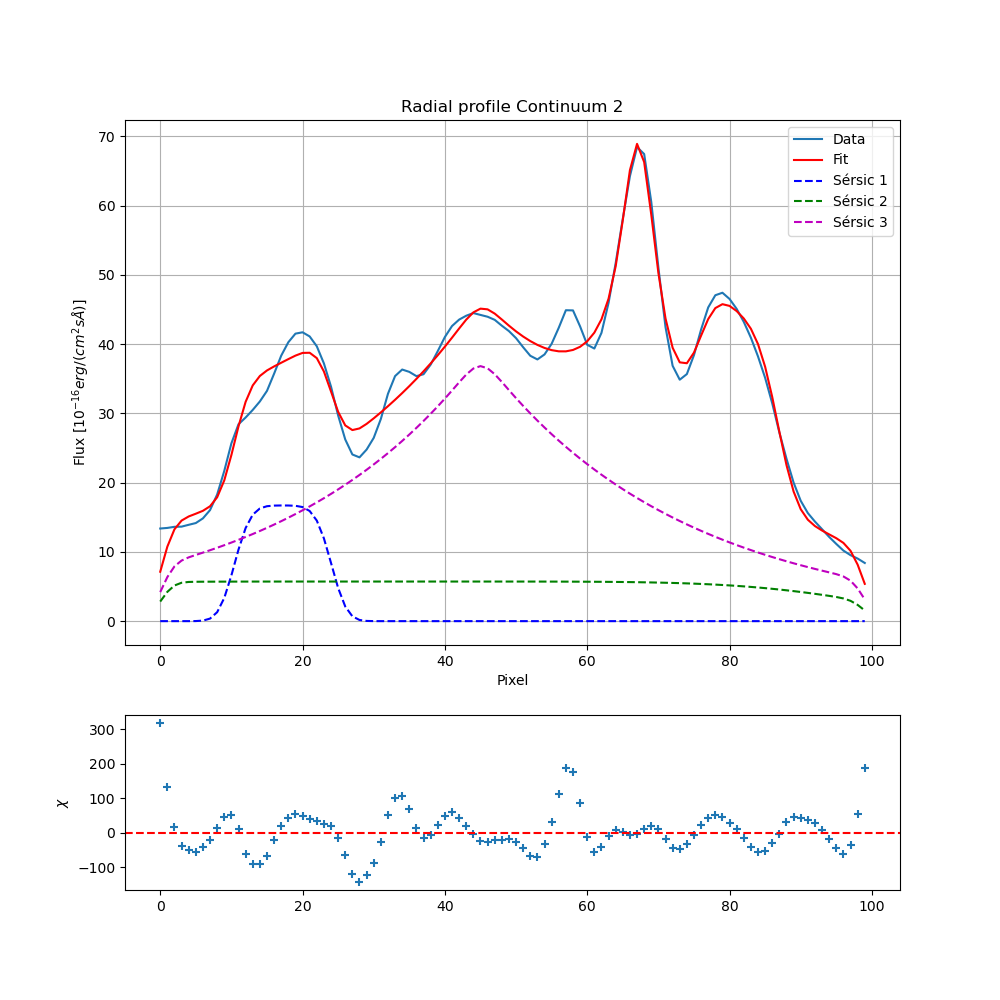

In [75]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, sigmas[5], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

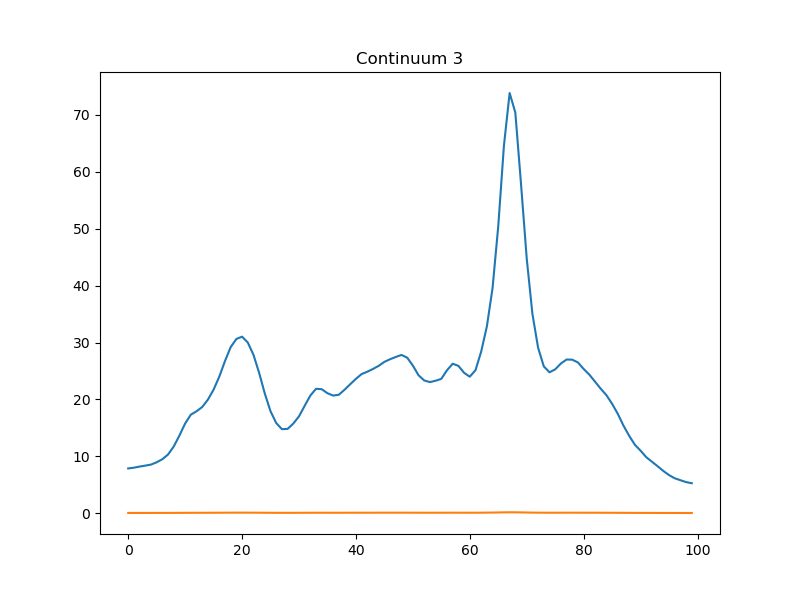

In [76]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [77]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 270285.73835295613
differential_evolution step 2: f(x)= 85775.15619430352
differential_evolution step 3: f(x)= 81450.50111138824
differential_evolution step 4: f(x)= 44542.66812423287
differential_evolution step 5: f(x)= 44542.66812423287
differential_evolution step 6: f(x)= 44542.66812423287
differential_evolution step 7: f(x)= 29851.52975548779
differential_evolution step 8: f(x)= 17974.775039647568
differential_evolution step 9: f(x)= 17974.775039647568
differential_evolution step 10: f(x)= 13521.519990789653
differential_evolution step 11: f(x)= 12145.66608251635
differential_evolution step 12: f(x)= 10173.247422694205
differential_evolution step 13: f(x)= 10173.247422694205
differential_evolution step 14: f(x)= 9601.313522369781
differential_evolution step 15: f(x)= 8710.460080001696
differential_evolution step 16: f(x)= 5976.280196039761
differential_evolution step 17: f(x)= 5886.83617464628
differential_evolution step 18: f(x)= 5886.836174646

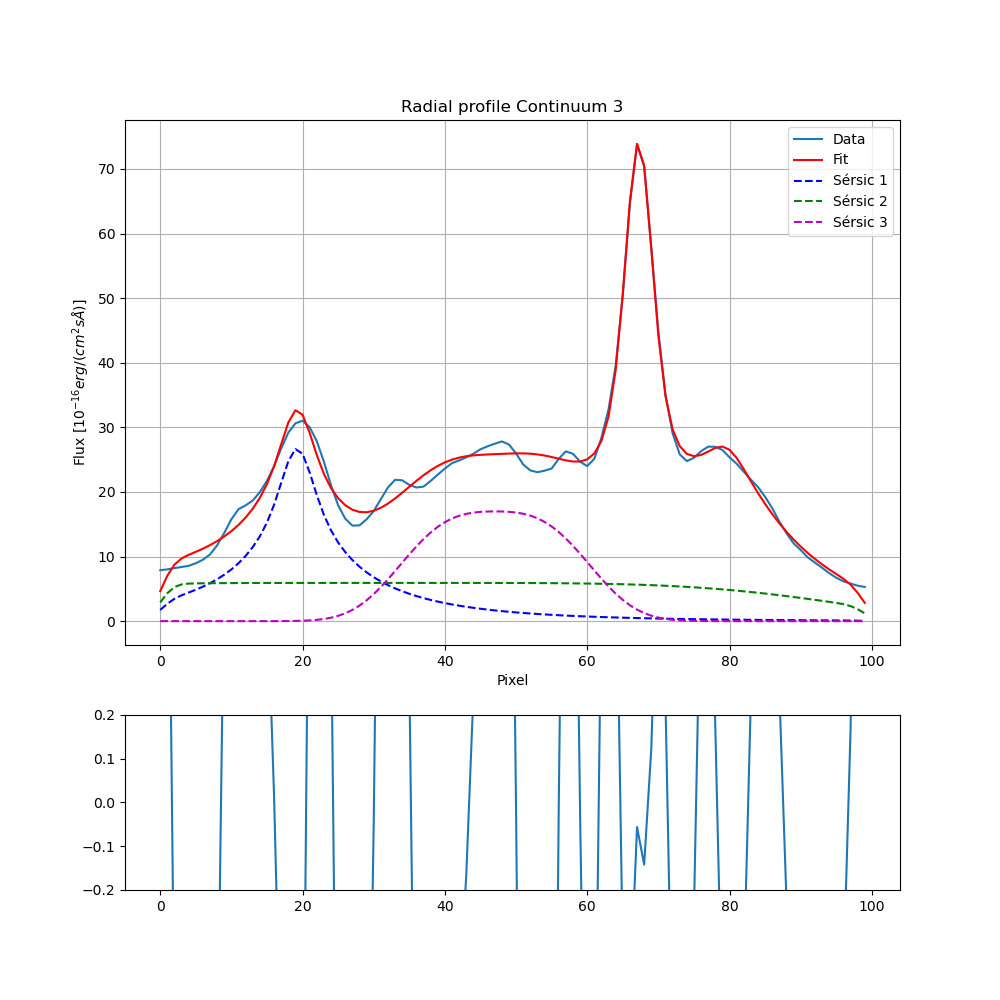

In [78]:
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [79]:
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = radial_profile_error_continuum_3)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          radial_profile_error_continuum_3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16052\1244895638.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16052\1244895638.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=4.9982, r_e=11.3760, n=1.0600, x_0=19.1582
Sérsic 2: I_e=4.3850, r_e=98.0572, n=0.0616, x_0=45.3518
Sérsic 3: I_e=15.1513, r_e=13.6242, n=0.2100, x_0=51.2439
Sérsic 4: I_e=23.3686, r_e=2.1078, n=0.8255, x_0=67.2663
Sérsic 5: I_e=10.4790, r_e=7.2006, n=0.4680, x_0=78.7021
[2.12941622e+00 7.91485445e+00 3.24437965e-01 2.00184999e-01
 2.07968116e+05 1.98833319e+06 2.95816707e+03 3.16248769e+05
 3.80339343e+00 5.60171848e+00 9.16846939e-02 8.23928384e+00
 1.76355250e+01 1.51669983e+00 6.55699305e-01 1.26360381e-01
 4.63457764e+00 1.65646633e+00 2.63678246e-01 4.04328217e+00]
205.8390472188908


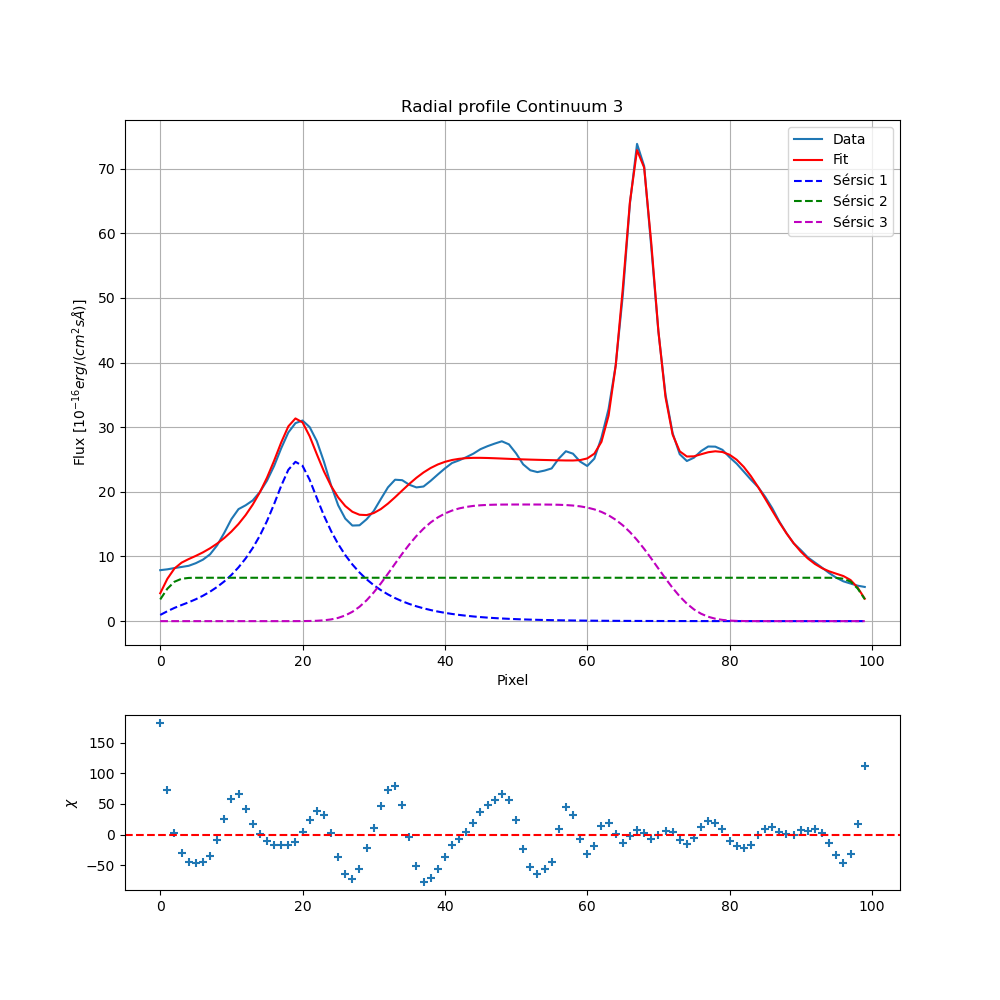

In [80]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [81]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII, 
           chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII, 
           dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII, 
           chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII', 'Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

In [82]:
bounds = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (10, 20),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 65),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (70, 80),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (90, 100)
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
